In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
combined_df = pd.read_pickle('/home/gaia/Projects/legacy_data/best_combined_gm_volumes.pkl')

df = combined_df.drop_duplicates(subset=['subject_id', 'session_id'])


In [4]:
print(f"Amount of unique subjects: {len(df['subject_id'].unique())}")
print(f"size of dataframe: {df.shape[0]}")
print(f" earliest scan date: {df['scan_date'].min()}")

Amount of unique subjects: 3673
size of dataframe: 4781
 earliest scan date: 20010907


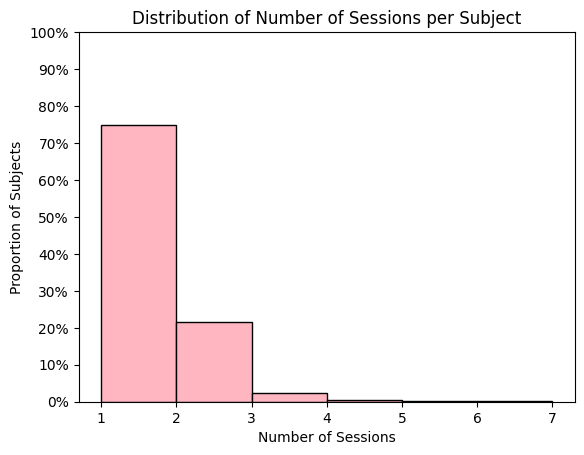

In [3]:
# how many subjects have how many sessions?
session_counts = df['subject_id'].value_counts()

plt.hist(session_counts, bins=np.arange(1, session_counts.max() + 1), density=True, color='lightpink', edgecolor='black')
plt.xlabel('Number of Sessions')
# yticks should be in percentage
plt.yticks(np.arange(0, 1.1, 0.1), [f'{int(x*100)}%' for x in np.arange(0, 1.1, 0.1)])
plt.ylabel('Proportion of Subjects')
plt.title('Distribution of Number of Sessions per Subject')
plt.show()

In [4]:
# repeated_subjects is df that contains subject_id of subjects that have more than 1 session
repeated_subjects = df[df['subject_id'].isin(session_counts[session_counts > 1].index)]
print(f"Number of unique subjects with more than 1 session: {repeated_subjects['subject_id'].nunique()}")

Number of unique subjects with more than 1 session: 923


In [5]:
print(repeated_subjects.columns)

Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path', 'scan_year',
       'classification_label'],
      dtype='object')


/tmp/ipykernel_234489/2934830907.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


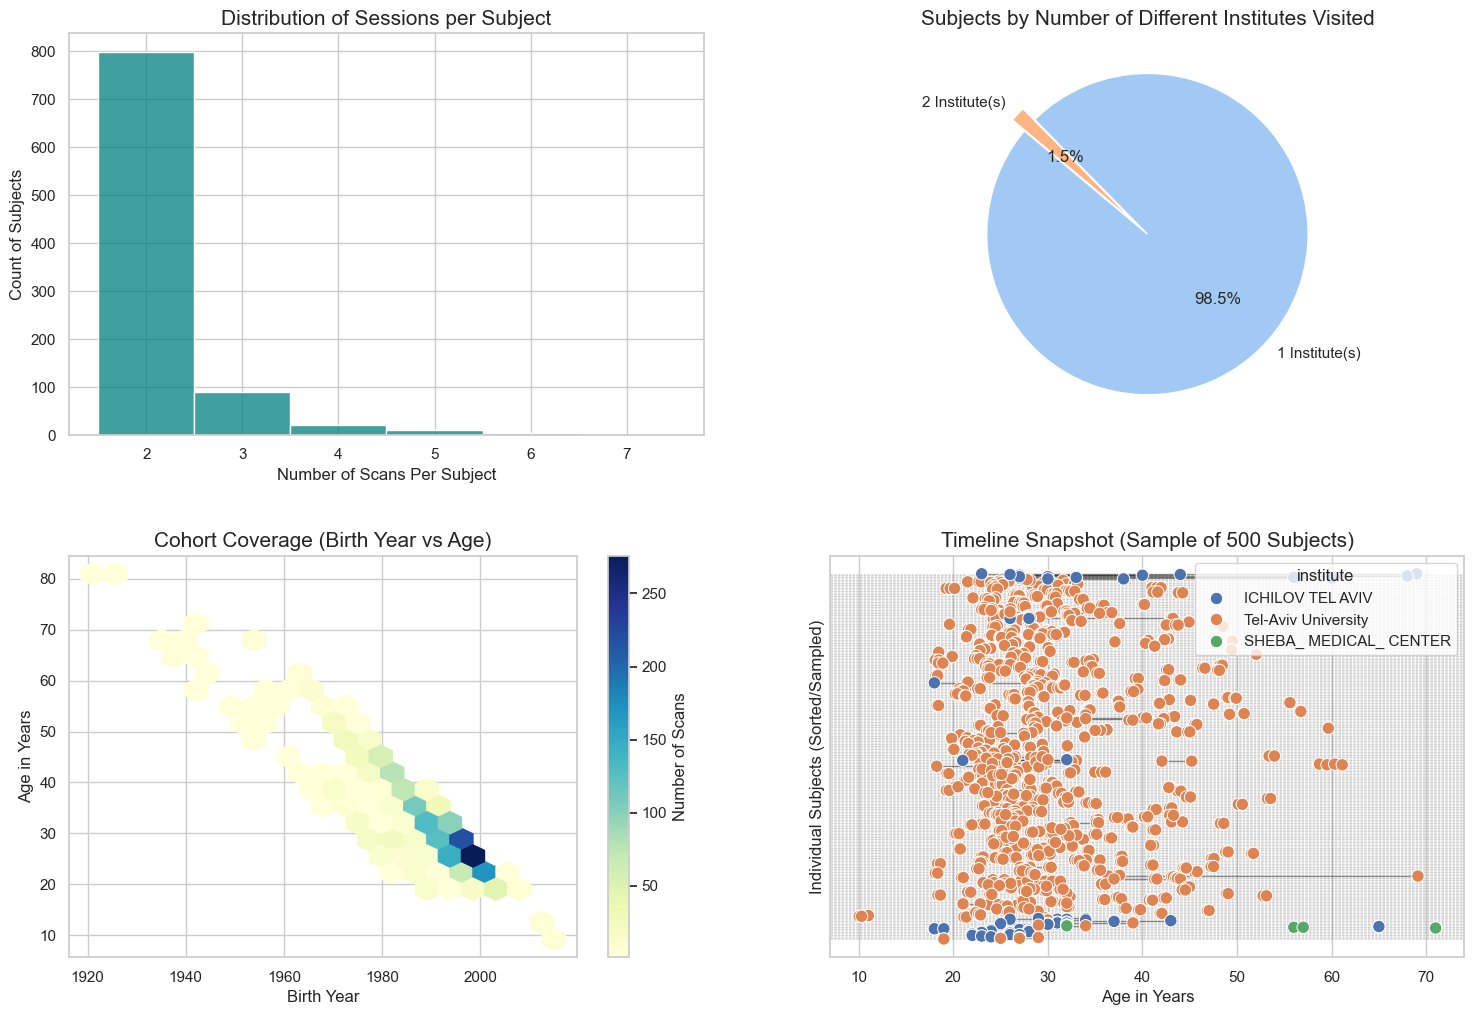

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. Data Processing for Plot 2 ---
# Count how many unique institutes each subject has been scanned at
inst_counts = repeated_subjects.groupby('subject_id')['institute'].nunique().value_counts().sort_index()

# Set aesthetic style
sns.set_theme(style="whitegrid")

# 1. Create a figure with a grid
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.2)

# --- Plot 1: Scan Frequency (How many sessions per person) ---
ax1 = fig.add_subplot(gs[0, 0])
session_counts = repeated_subjects.groupby('subject_id')['session_id'].nunique()
sns.histplot(session_counts, discrete=True, color='teal', ax=ax1)
ax1.set_title('Distribution of Sessions per Subject', fontsize=15)
ax1.set_xlabel('Number of Scans Per Subject')
ax1.set_ylabel('Count of Subjects')

# --- Plot 2: Pie Chart (Institutes per Subject) ---
ax2 = fig.add_subplot(gs[0, 1])
# Using a pie chart to show the proportion of single-site vs multi-site subjects
ax2.pie(inst_counts, 
        labels=[f"{i} Institute(s)" for i in inst_counts.index], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=sns.color_palette('pastel'),
        explode=[0.1 if i > 1 else 0 for i in inst_counts.index]) # Highlight multi-site subjects
ax2.set_title('Subjects by Number of Different Institutes Visited', fontsize=15)


# --- Plot 3: Lexis Diagram (Birth Year vs Age at Scan) ---
ax3 = fig.add_subplot(gs[1, 0])
# Using hexbin to handle high density of 923 subjects
hb = ax3.hexbin(repeated_subjects['birth_year'], repeated_subjects['age_in_years'], 
                gridsize=20, cmap='YlGnBu', mincnt=1)
fig.colorbar(hb, ax=ax3, label='Number of Scans')
ax3.set_title('Cohort Coverage (Birth Year vs Age)', fontsize=15)
ax3.set_xlabel('Birth Year')
ax3.set_ylabel('Age in Years')

# --- Plot 4: Sampled Longitudinal Timeline ---
ax4 = fig.add_subplot(gs[1, 1])

# Sampling and sorting for a cleaner visual
n_sample = 500
sample_ids = (repeated_subjects.drop_duplicates('subject_id')
              .sort_values('birth_year') # Sorting by birth year makes trends visible
              ['subject_id'].sample(n_sample))

df_sample = repeated_subjects[repeated_subjects['subject_id'].isin(sample_ids)].copy()

# Add horizontal axial lines for each subject
# This creates a 'track' for each subject's repeated measures
for i, sub_id in enumerate(df_sample['subject_id'].unique()):
    ax4.axhline(y=sub_id, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Connect the dots with lines
sns.lineplot(data=df_sample, x='age_in_years', y='subject_id', units='subject_id', 
             estimator=None, color='black', linewidth=1, alpha=0.4, ax=ax4)

# Plot the individual scans
sns.scatterplot(data=df_sample, x='age_in_years', y='subject_id', 
                hue='institute', s=80, edgecolor='white', zorder=5, ax=ax4)

ax4.set_title(f'Timeline Snapshot (Sample of {n_sample} Subjects)', fontsize=15)
ax4.set_ylabel('Individual Subjects (Sorted/Sampled)')
ax4.set_xlabel('Age in Years')
ax4.set_yticks([]) # Keep clean by removing messy ID strings

plt.tight_layout()
plt.show()

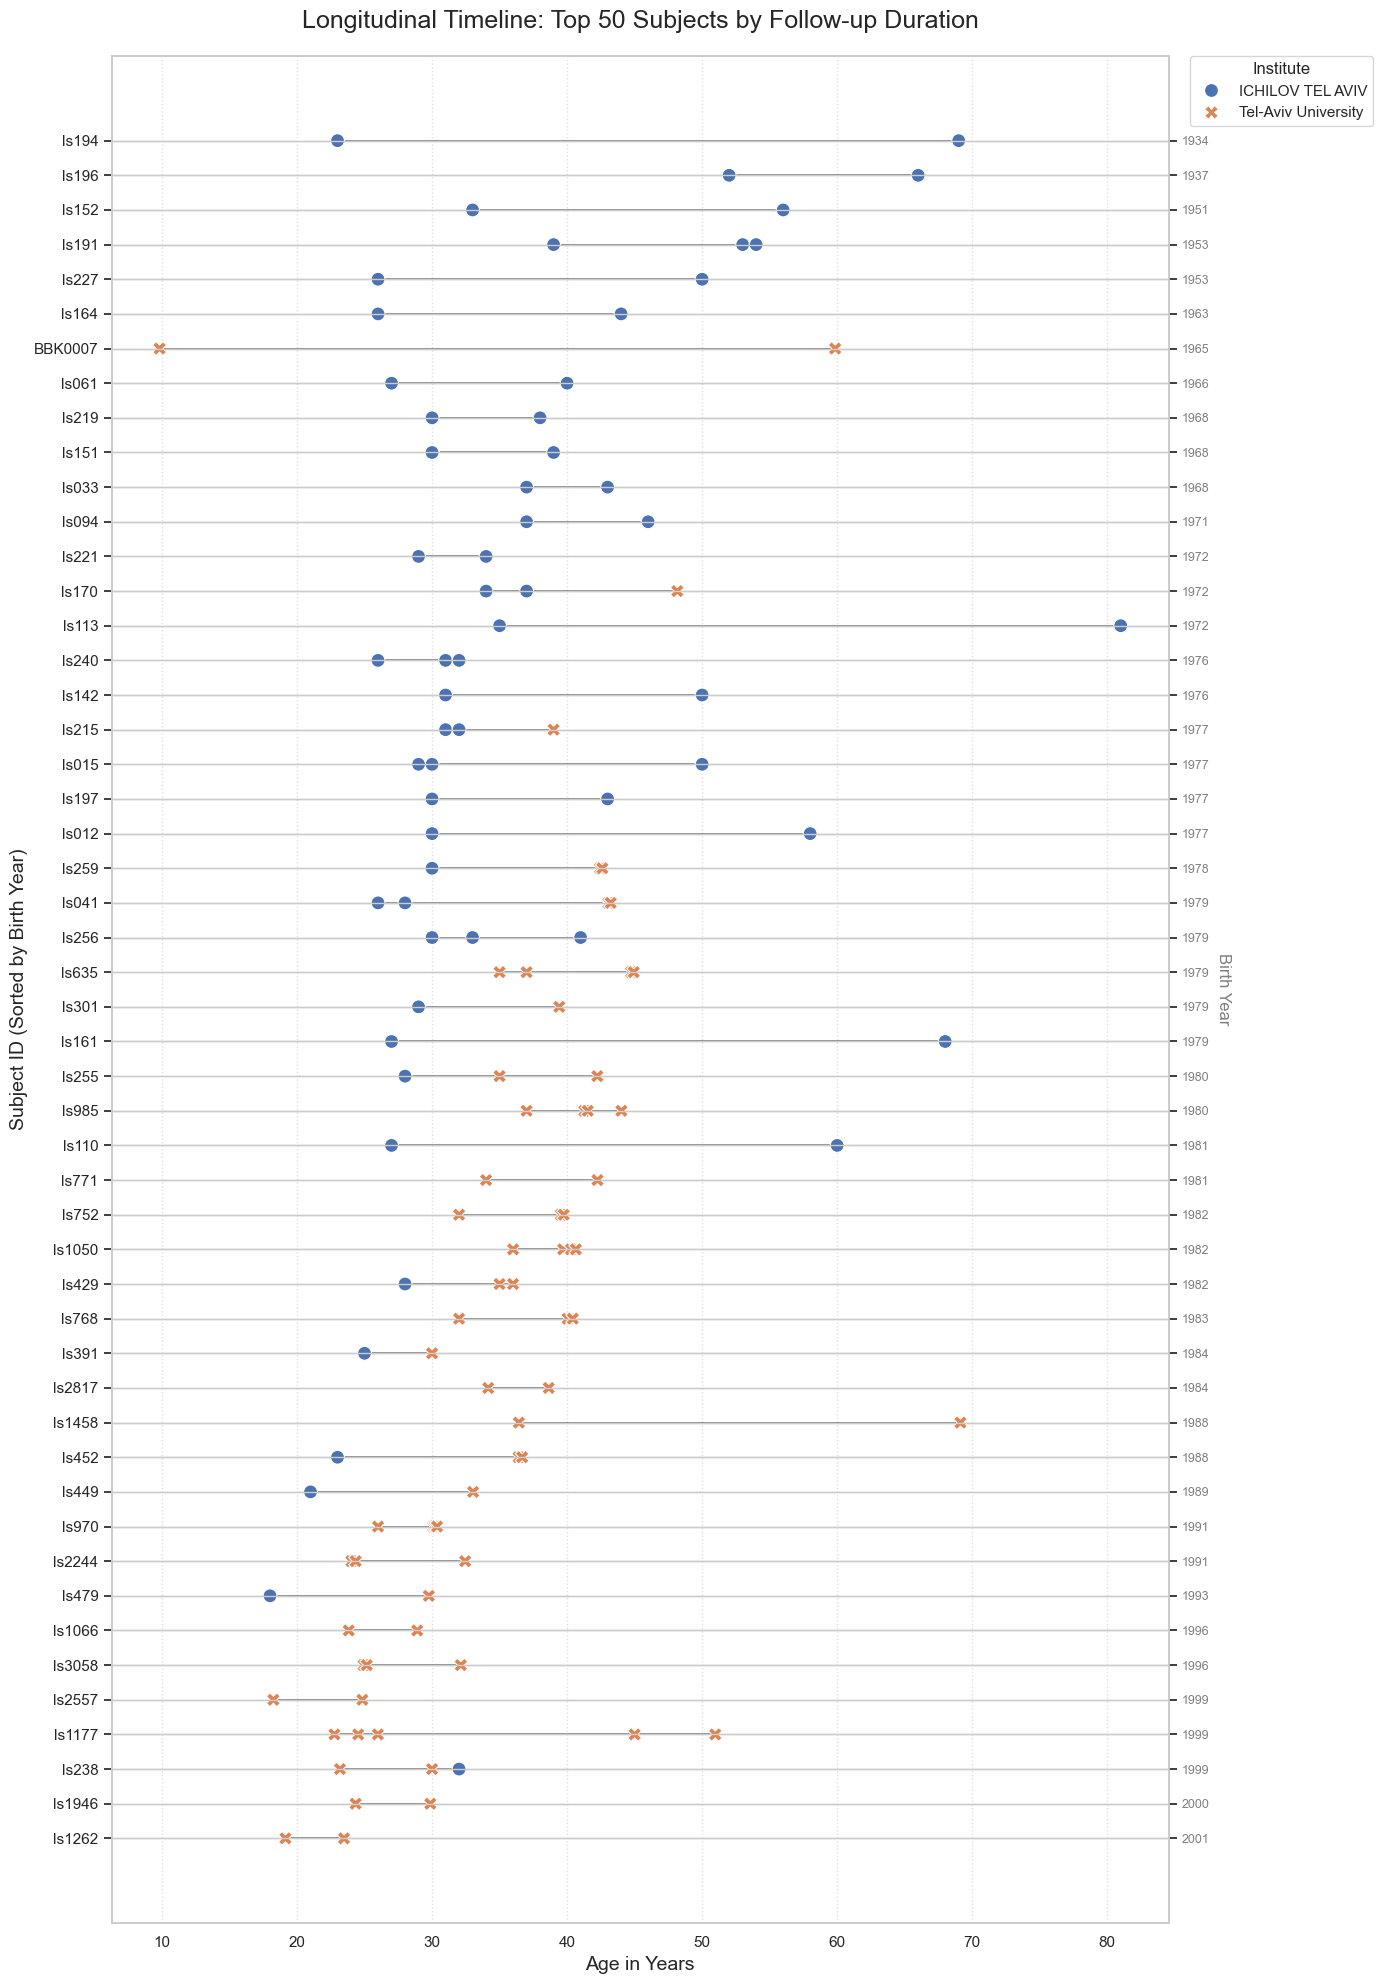

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Ensure 'age_in_years' is numeric (important to avoid the TypeError)
# errors='coerce' will turn non-numeric values into NaN
repeated_subjects['age_in_years'] = pd.to_numeric(repeated_subjects['age_in_years'], errors='coerce')

# 2. Calculate the age span for each subject
# We drop NaNs in age for this calculation to ensure 'min' and 'max' work correctly
subject_gaps = repeated_subjects.dropna(subset=['age_in_years']).groupby('subject_id')['age_in_years'].agg(['min', 'max', 'count'])
subject_gaps['span'] = subject_gaps['max'] - subject_gaps['min']

# Force 'span' to be numeric just in case
subject_gaps['span'] = pd.to_numeric(subject_gaps['span'], errors='coerce')

# 3. Select the top N subjects with the largest gaps
n_top = 50 
top_subjects_ids = subject_gaps.nlargest(n_top, 'span').index

# 4. Filter the dataframe and prepare for plotting
df_top = repeated_subjects[repeated_subjects['subject_id'].isin(top_subjects_ids)].copy()

# Sort subjects by birth_year for the Y-axis flow
# We handle cases where birth_year might also be a string
df_top['birth_year'] = pd.to_numeric(df_top['birth_year'], errors='coerce')
sorted_subjects = (df_top.drop_duplicates('subject_id')
                   .sort_values('birth_year')['subject_id']
                   .tolist())

# --- Plotting ---
plt.figure(figsize=(14, 20)) 
ax = plt.gca()

# Draw horizontal axial lines for each subject track
for sub_id in sorted_subjects:
    plt.axhline(y=sub_id, color='gray', linestyle='--', linewidth=0.5, alpha=0.3)

# Connect the sessions with a line
# Using 'hue' inside lineplot can sometimes split lines, so we use 'units' to keep subject lines solid
sns.lineplot(data=df_top, x='age_in_years', y='subject_id', units='subject_id', 
             estimator=None, color='black', linewidth=1.2, alpha=0.5)

# Plot the individual scans with Institute information
sns.scatterplot(data=df_top, x='age_in_years', y='subject_id', 
                hue='institute', style='institute', s=100, 
                edgecolor='white', zorder=5)

# Formatting
plt.title(f'Longitudinal Timeline: Top {n_top} Subjects by Follow-up Duration', fontsize=18, pad=20)
plt.xlabel('Age in Years', fontsize=14)
plt.ylabel('Subject ID (Sorted by Birth Year)', fontsize=14)
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Move legend outside the plot
plt.legend(title='Institute', bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)

# Add birth year labels to the right Y-axis for context
ax2 = ax.twinx()
ax2.set_ylim(ax.get_ylim())
# Create matching list of birth years for the sorted subjects
birth_years_dict = df_top.drop_duplicates('subject_id').set_index('subject_id')['birth_year'].to_dict()
birth_year_labels = [int(birth_years_dict[sid]) if pd.notnull(birth_years_dict[sid]) else "" for sid in sorted_subjects]

ax2.set_yticks(range(len(sorted_subjects)))
ax2.set_yticklabels(birth_year_labels, fontsize=9, color='gray')
ax2.set_ylabel('Birth Year', color='gray', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

In [8]:
# entries that don't make sense - age_in_year - birth_year < 2000
invalid_entries = repeated_subjects[(repeated_subjects['age_in_years'] + repeated_subjects['birth_year']) < 2000]
print(f"Number of entries with age_in_years - birth_year < 2000: {len(invalid_entries)}")
print(invalid_entries[['subject_id', 'age_in_years', 'birth_year']])

Number of entries with age_in_years - birth_year < 2000: 0
Empty DataFrame
Columns: [subject_id, age_in_years, birth_year]
Index: []


# debug combined_df

In [9]:
print(df.columns)


Index(['subject_id', 'session_id', 'region_label', 'tissue_type', 'volume_mm3',
       'tiv', 'sex', 'institute', 'manufacturer', 'age_in_years', 'dob',
       'gm_volume_cm3', 'protocol', 'source', 'birth_year', 'unnamed: 0',
       'atlas_name', 'scan_time', 'age_at_scan', 'weight', 'directory_path',
       'estimated_critical_info', 'scan_date', 'file_path', 'scan_year',
       'classification_label'],
      dtype='object')


things that dont make sense - more than 1 dob, more than 1 sex, 
for a single session_id, age_in_years gap of more than 20 years

for each of these cases print the subject_id, session_id and source

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import math

# --- 1. Identify Issues by Subject ---
def identify_subject_issues(group):
    issues = []
    # 1. Check for multiple DOBs
    if group['dob'].nunique() > 1:
        issues.append('dob')
    # 2. Check for multiple Sex entries
    if group['sex'].nunique() > 1:
        issues.append('sex')
    # 3. Check for age gaps > 20 years
    if (group['age_in_years'].max() - group['age_in_years'].min()) > 20:
        issues.append('age_gap')
            
    return ", ".join(issues) if issues else None

# --- 2. Process the DataFrame ---
# Generate mapping and apply to main df
issue_mapping = df.groupby('subject_id').apply(identify_subject_issues)
df['issue'] = df['subject_id'].map(issue_mapping)

# Filter for the report
report_df = df[df['issue'].notna()].copy()

Charts generated: 'pie_issues_per_source.png' and 'pie_sources_per_issue.png'
        subject_id session_id                    source         issue
0            ls191   20070322                  gnbb_CDs      dob, sex
454          ls191   20071021                  gnbb_CDs      dob, sex
1362         ls194   20030915                  gnbb_CDs  dob, age_gap
2270         ls113   20070130                  gnbb_CDs  dob, age_gap
2724         ls164   20080201                  gnbb_CDs      dob, sex
...            ...        ...                       ...           ...
2178340      ls498   20120628  HardDrive_under_thirties           dob
2210574      ls620   20150226  HardDrive_under_thirties           dob
2211028      ls620   20150920  HardDrive_under_thirties           dob
2231004      ls747   20151012  HardDrive_under_thirties      dob, sex
2262329      ls970   20171231  HardDrive_under_thirties           dob

[256 rows x 4 columns]


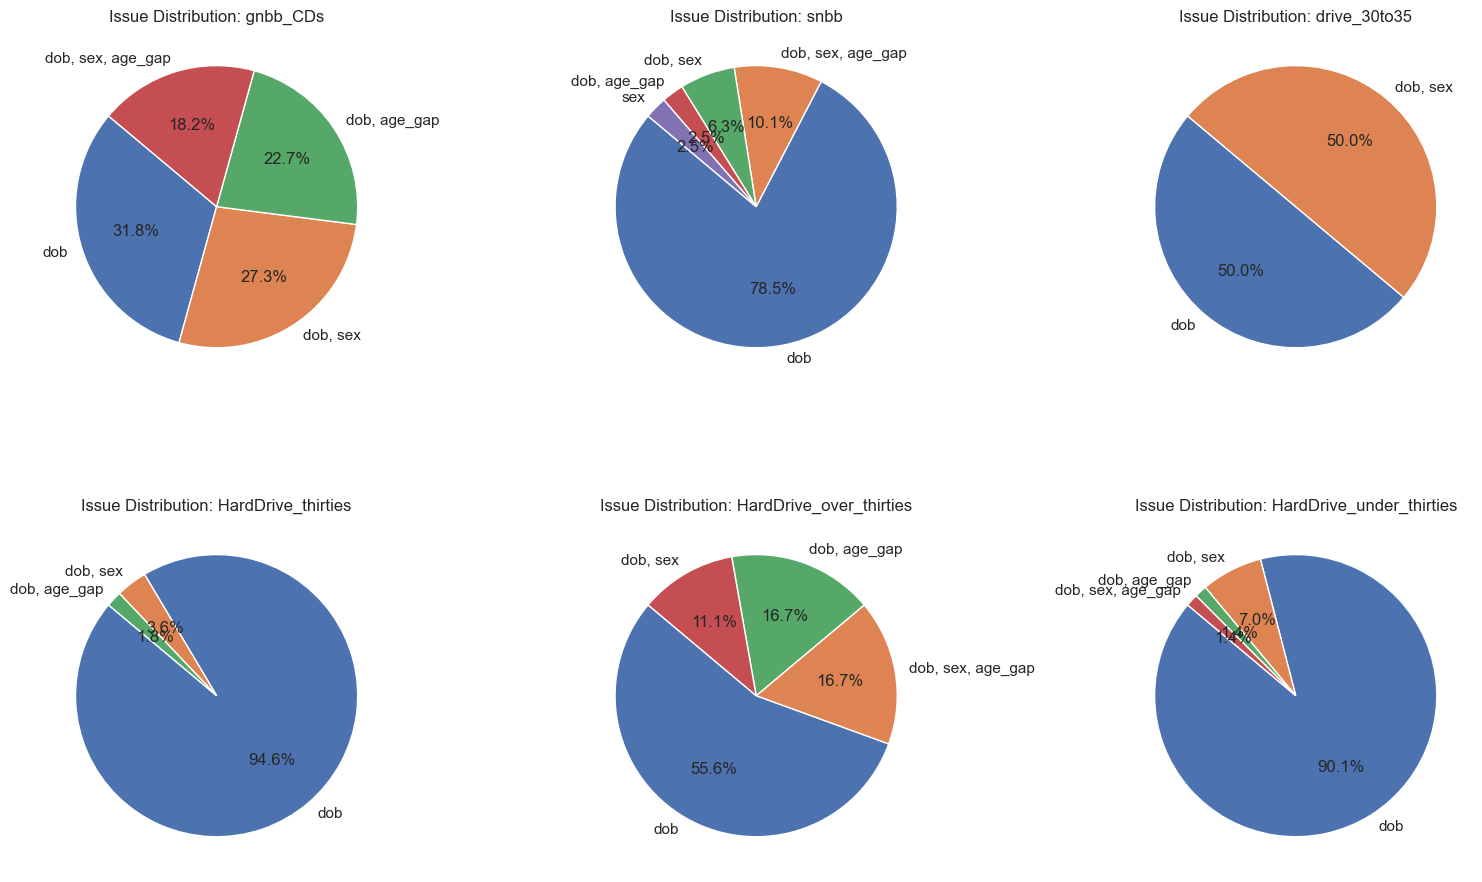

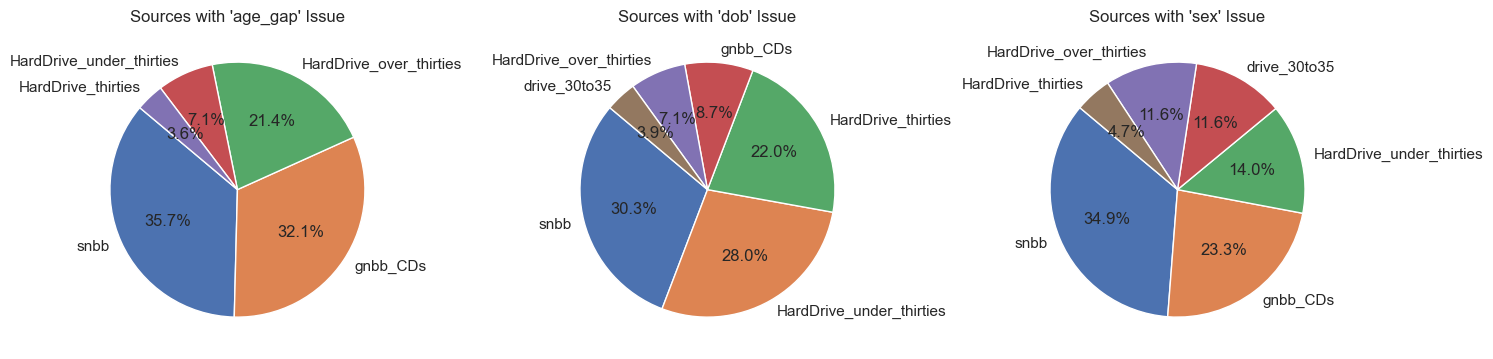

In [11]:
# --- 3. Plotting ---
if report_df.empty:
    print("No issues found to plot.")
else:
    # Setup for multiple charts
    cols = 3
    
    # -- PLOT 1: Pie chart per source (showing which issues it has) --
    unique_sources = report_df['source'].unique()
    n_src = len(unique_sources)
    rows_src = math.ceil(n_src / cols)
    
    fig1, axes1 = plt.subplots(rows_src, cols, figsize=(15, 5 * rows_src))
    axes1 = axes1.flatten() if n_src > 1 else [axes1]
    
    for i, source in enumerate(unique_sources):
        src_subset = report_df[report_df['source'] == source]
        # Count the specific issue combinations found in this source
        counts = src_subset['issue'].value_counts()
        axes1[i].pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=140)
        axes1[i].set_title(f"Issue Distribution: {source}")
    
    # Hide any empty subplots
    for j in range(i + 1, len(axes1)): axes1[j].axis('off')
    plt.tight_layout()
    plt.savefig('pie_issues_per_source.png')

    # -- PLOT 2: Pie chart per issue (showing which sources contribute to it) --
    # Find all unique individual issue types (splitting "dob, sex" -> "dob", "sex")
    all_tags = set()
    for row in report_df['issue'].unique():
        all_tags.update([t.strip() for t in row.split(',')])
    unique_issue_types = sorted(list(all_tags))
    
    n_iss = len(unique_issue_types)
    rows_iss = math.ceil(n_iss / cols)
    
    fig2, axes2 = plt.subplots(rows_iss, cols, figsize=(15, 5 * rows_iss))
    axes2 = axes2.flatten() if n_iss > 1 else [axes2]
    
    for i, issue_type in enumerate(unique_issue_types):
        # Filter for any row that includes this specific issue type
        iss_subset = report_df[report_df['issue'].str.contains(issue_type)]
        src_counts = iss_subset['source'].value_counts()
        axes2[i].pie(src_counts, labels=src_counts.index, autopct='%1.1f%%', startangle=140)
        axes2[i].set_title(f"Sources with '{issue_type}' Issue")
        
    for j in range(i + 1, len(axes2)): axes2[j].axis('off')
    plt.tight_layout()
    plt.savefig('pie_sources_per_issue.png')

    print("Charts generated: 'pie_issues_per_source.png' and 'pie_sources_per_issue.png'")
    print(report_df[['subject_id', 'session_id', 'source', 'issue']])

In [12]:
# for each subject_id, collect all associated issues
subject_issues = df.groupby('subject_id')['issue'].apply(lambda x: ', '.join(x.dropna())).to_dict()
# remove empty subject_id
subject_issues = {k: v for k, v in subject_issues.items() if v}